In [1]:
import scion
import ENDFtk

In [2]:
# ENDF/B-VI.8 data for Cm244
cm244_endf68 = ENDFtk.tree.Tape.from_file( '/Users/wim/Projects/libraries/endf/endf68/neutrons/n-96244.endf' )

data_endf68 = scion.from_endf( cm244_endf68.materials.front().file(1).section(452).parse() )

# the nubar data is given as a polynomial series
print( data_endf68 )
print( data_endf68.coefficients )

# linearise the data
data_endf68 = data_endf68.linearise()

# the nubar data is now a lin-lin table
print( data_endf68 )
print( data_endf68.x )
print( data_endf68.y )

[3.46, 1.84e-07]
[1e-05, 20000000.0]
[3.46000000000184, 7.140000000000001]


In [3]:
# ENDF/B-VIII.0 data for Cm244
cm244_endf80 = ENDFtk.tree.Tape.from_file( '/Users/wim/Projects/libraries/endf/endf80/neutrons/n-096_Cm_244.endf' )

data_endf80 = scion.from_endf( cm244_endf80.materials.front().file(1).section(452).parse() )

# the nubar data is a lin-lin table
print( data_endf80 )
print( data_endf80.x )
print( data_endf80.y )

[9.999999999999999e-06, 500000.0, 1000000.0, 2000000.0, 3000000.0, 4000000.0, 5000000.0, 6000000.0, 7000000.0, 8000000.0, 9000000.0, 10000000.0, 12000000.0, 14000000.0, 15000000.0, 16000000.0, 18000000.0, 20000000.0]
[3.463651, 3.5280009999999997, 3.592351, 3.7202509999999998, 3.8475509999999997, 3.97415, 4.10004, 4.224183, 4.348204, 4.472427, 4.596698, 4.718049, 4.960787, 5.203529, 5.324866, 5.443302, 5.680222, 5.917184]


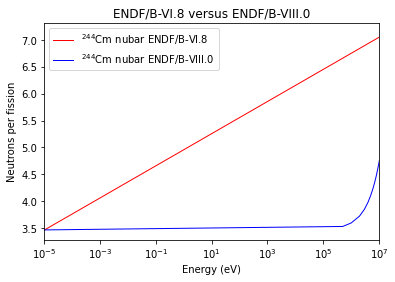

In [4]:
import matplotlib.pyplot as plot

# plot the data
plot.figure()
plot.plot( data_endf68.x, data_endf68.y, label = '${}^{244}$Cm nubar ENDF/B-VI.8', color = 'red', linewidth = 1.0 )
plot.plot( data_endf80.x, data_endf80.y, label = '${}^{244}$Cm nubar ENDF/B-VIII.0', color = 'blue', linewidth = 1.0 )
plot.xlabel( 'Energy (eV)' )
plot.ylabel( 'Neutrons per fission' )
plot.title( 'ENDF/B-VI.8 versus ENDF/B-VIII.0' )
plot.xlim( 1e-5, 10e+6 )
plot.xscale( 'log' )
plot.yscale( 'linear' )
plot.legend()
plot.show()